# Permafrost Exercise

## Permafrost fraction as a function of mean annual air temperature (MAAT)

Despite progress in process-based modelling on local and regional scales, a lack of data availability and model limitations cause permafrost still being poorly simulated in global climate models. 

Large-scale permafrost thaw can be projected using an observation-based relationship (see below) between permafrost probability and mean annual air temperatue (MAAT), statistically accounting for other determining factors such as topography, soil properties, snow and hydrology. Over large spatial scales the probability translates to permafrost fraction. 

In this exercise, we will apply this relationship to climate model output to explore permafrost occurence in historical periods and in future climate scenarios.

In [1]:
# Import python packages
import xarray as xr
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cf
import scipy
from glob import glob

%matplotlib inline

# constants
fp = 273.15 # freezing point in K

In [2]:
# Relationship Permafrost Fraction and MAAT (Gruber 2012)
def PF(MAAT, mu, sigma):
    PF = 0.5 * scipy.special.erfc( (MAAT+mu)/(2*sigma**2)**0.5 )
    return PF
    
# from Chadburn et al. (2017)
mu_chad = 4.38
sigma_chad = (2.59)**0.5 
mu_max_chad = 3.05
sigma_max_chad = (4.97)**0.5 
mu_min_chad = 6.53
sigma_min_chad = (5.57)**0.5

Text(0.5, 1.0, ' ')

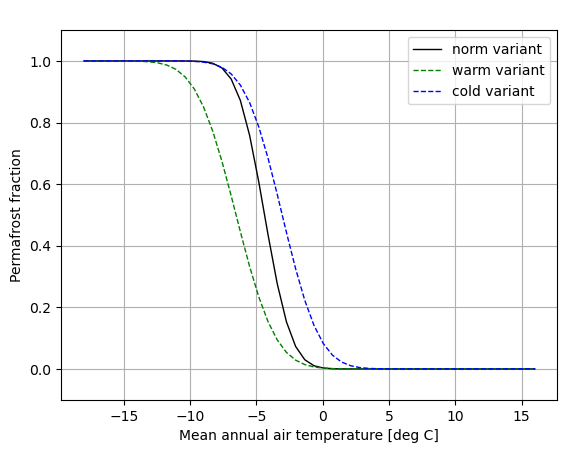

In [3]:
# inspect relationship
MAAT = np.linspace(-18,16)

mylinewidth=1
mylinestyle='--'

mycolor1='black'
plt.plot(MAAT, PF(MAAT,mu_chad, sigma_chad), color = mycolor1,linewidth=mylinewidth,label = 'norm variant')
plt.plot(MAAT, PF(MAAT,mu_min_chad, sigma_min_chad), color = 'green', linewidth=mylinewidth,linestyle=mylinestyle, label = 'warm variant')
plt.plot(MAAT, PF(MAAT,mu_max_chad, sigma_max_chad), color = 'blue',linewidth=mylinewidth,linestyle=mylinestyle, label = 'cold variant')

plt.legend()
plt.grid()
plt.xlabel('Mean annual air temperature [deg C]')
plt.ylabel('Permafrost fraction')
plt.ylim((-0.1,1.1))
plt.title(' ')

## Permafrost Fraction from NorESM2-MM

**Task: Read in the monthly surface temperature data of NorESM2-MM for the historical period 1960-1990 (choose ensemble member r1i1p1f1). Combine the necessary files by coordinates.**

In [ ]:
# read in data
# NorESM
path = '/mnt/clinfra-ns12127k-ns9034k-cmip6/CMIP/NCC/NorESM2-LM/historical/r1i1p1f1/Amon/tas/gn/latest/' # NorESM2-MM has a res of ~1deg
files=list(glob(path+"tas*.nc"))
files.sort()
files = files[-6:-3]
tas_Amon = xr.open_mfdataset(files, combine='by_coords')

**Task: Calculate the mean surface air temperature in degrees Celsius during this period for each gridcell**.

In [7]:
tas_mean_1960_1990 = 

**Task: Calculate the permafrost fraction** <br>
Apply the function PF(MAAT, mu, sigma) to the mean surface air temperatures. <br>
Use $\mu =\mu_{chad}$ and $\sigma= \sigma_{chad}$ as parameters for the function. <br>
Hint: You can update the name of your newly created variable using variablename.rename('newname').

In [10]:
PF_cont =



**Task: Display the permafrost fraction** <br>
Plot the permafrost fraction of the circumarctic region from 24 to 90 deg North as a North Polar Stereo projection ( projection=ccrs.NorthPolarStereo() ). <br>
You can change the extend of the map using << ax.set_extent([lon_min, lon_max, lat_min, Lat_max], ccrs.PlateCarree() >> <br>

**Task: Mask out the ocean gridcells**<br>
Use the lsurface tile land fraction (sftlf) output of NorESM2-MM (below) to categorize all gridcells with with $sftlf>0.5$ as land landsurface and display only these.

In [24]:
# land area coverage
files=list(glob(path+"../../../../fx/sftlf/gn/latest/*.nc"))
sftlf = xr.open_mfdataset(files)

In [ ]:
# masked map




**Task: Categorize the different permafrost zones**<br>
Apply the following mask to the obtained permafrost fraction.<br>
PF=0:        no permafrost <br>
0<PF<=0.1:   no or isolated permafrost <br>
0.1<PF<=0.5: sporadic permafrost <br>
0.5<PF<=0.9: discontinuous permafrost <br>
PF>0.9 :     continuous permafrost<br>

Display the output and discuss it with your neighbour. What is surpring to you? Can you think of limitations of this method and and it's input data from NorESM2-MM? Where can we not trust the map?

In [ ]:
# IPA permafrost masks none - none/isolated - sporadic -discontinuous - continuous 
PF_mask = xr.where( PF_cont == 0.0, 0, float('nan'))
PF_mask = xr.where( PF_cont > 0.01, 1, PF_mask)
PF_mask = xr.where( PF_cont > 0.1, 2, PF_mask)
PF_mask = xr.where( PF_cont > 0.5, 3, PF_mask)
PF_mask = xr.where( PF_cont > 0.9 , 4, PF_mask)

PF_mask = PF_mask.rename('permafrost zones')

**Task: How will the permafrost thaw under SSP585?** <br>
Create the same map with the SSP585 output of NorESM for the period of 2040-2070. <br>
Where does the permafrost thaw? Compare your results to the soil carbon content map from the lecture. Discuss uncertainties.<br>

**Bonustask: Look into different climate scenarios / models**